# Hybrid CNN-CBAM-Swin Transformer for Multi-Class GI Disease Classification (Kvasir Dataset)

**This is the consolidated version** -- baseline models (PlainCNN, CNN+CBAM, pretrained Swin-Tiny, MultiScale_CBAM_Fusion) plus the Cross-Attention CNN+Swin dual-branch proposed model. It includes consistent fine-tuning LR, multi-scale fusion, pretrained Swin-Tiny via keras_hub, Grad-CAM, sample input, and augmentation-count reporting.


In [1]:
!pip install -q -U keras-hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 66.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.31.1 which is incompatible.


In [2]:
# ============================================================
# 1. SETUP & IMPORTS
# ============================================================
import os, glob, math, random, copy
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import to_categorical
import keras_hub

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, roc_auc_score, roc_curve, classification_report)

import albumentations as A

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

IMG_SIZE = 256
SWIN_SIZE = 224
BATCH_SIZE = 8
EPOCHS = 100

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ============================================================
# 2. LOCATE DATASET (auto-discovers class folders under /kaggle/input)
# ============================================================
BASE_DIR = "/kaggle/input"

candidate_dirs = glob.glob(os.path.join(BASE_DIR, "**"), recursive=False)
print("Top-level input dirs:", candidate_dirs)

def find_class_folders(root):
    class_folders = []
    for dirpath, dirnames, filenames in os.walk(root):
        img_files = [f for f in filenames if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if len(img_files) > 20:
            class_folders.append(dirpath)
    return class_folders

class_folders = []
for d in candidate_dirs:
    class_folders.extend(find_class_folders(d))

class_folders = sorted(set(class_folders))
print(f"Found {len(class_folders)} class folders:")
for cf in class_folders:
    n = len([f for f in os.listdir(cf) if f.lower().endswith(('.jpg','.jpeg','.png'))])
    print(f"  {cf}  -> {n} images")


Top-level input dirs: ['/kaggle/input/datasets', '/kaggle/input/models']
Found 8 class folders:
  /kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/dyed-lifted-polyps  -> 500 images
  /kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/dyed-resection-margins  -> 500 images
  /kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/esophagitis  -> 500 images
  /kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/normal-cecum  -> 500 images
  /kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/normal-pylorus  -> 500 images
  /kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/normal-z-line  -> 500 images
  /kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/polyps  -> 500 images
  /kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/ulcerative-colitis  -> 500 images


In [4]:
# ============================================================
# 3. BUILD FILE LIST + LABELS
# ============================================================
CLASS_NAMES = sorted([os.path.basename(cf) for cf in class_folders])
NUM_CLASSES = len(CLASS_NAMES)
print("NUM_CLASSES set to:", NUM_CLASSES)
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
print("Classes:", CLASS_NAMES)

filepaths, labels = [], []
for cf in class_folders:
    cname = os.path.basename(cf)
    imgs = glob.glob(os.path.join(cf, "*.jpg")) + glob.glob(os.path.join(cf, "*.jpeg")) + glob.glob(os.path.join(cf, "*.png"))
    for p in imgs:
        filepaths.append(p)
        labels.append(class_to_idx[cname])

df = pd.DataFrame({"filepath": filepaths, "label": labels})
print(df['label'].value_counts())
print("Total images:", len(df))


NUM_CLASSES set to: 8
Classes: ['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']
label
0    500
1    500
2    500
3    500
4    500
5    500
6    500
7    500
Name: count, dtype: int64
Total images: 4000


In [5]:
# ============================================================
# 4. TRAIN / VAL / TEST SPLIT (80 / 10 / 10)
# ============================================================
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
train_df['label'].value_counts(), val_df['label'].value_counts(), test_df['label'].value_counts()


Train: 3200  Val: 400  Test: 400


(label
 3    400
 1    400
 7    400
 0    400
 2    400
 5    400
 4    400
 6    400
 Name: count, dtype: int64,
 label
 4    50
 5    50
 3    50
 1    50
 7    50
 2    50
 6    50
 0    50
 Name: count, dtype: int64,
 label
 3    50
 7    50
 4    50
 2    50
 6    50
 0    50
 1    50
 5    50
 Name: count, dtype: int64)

In [6]:
# ============================================================
# 5. PREPROCESSING: CLAHE (clip=2.0, tile 8x8, LAB L-channel)
# ============================================================
def apply_clahe(img_rgb):
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l2 = clahe.apply(l)
    lab2 = cv2.merge((l2, a, b))
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)

def load_and_preprocess(path, size=IMG_SIZE):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    img = apply_clahe(img)
    img = img.astype(np.float32) / 255.0
    return img


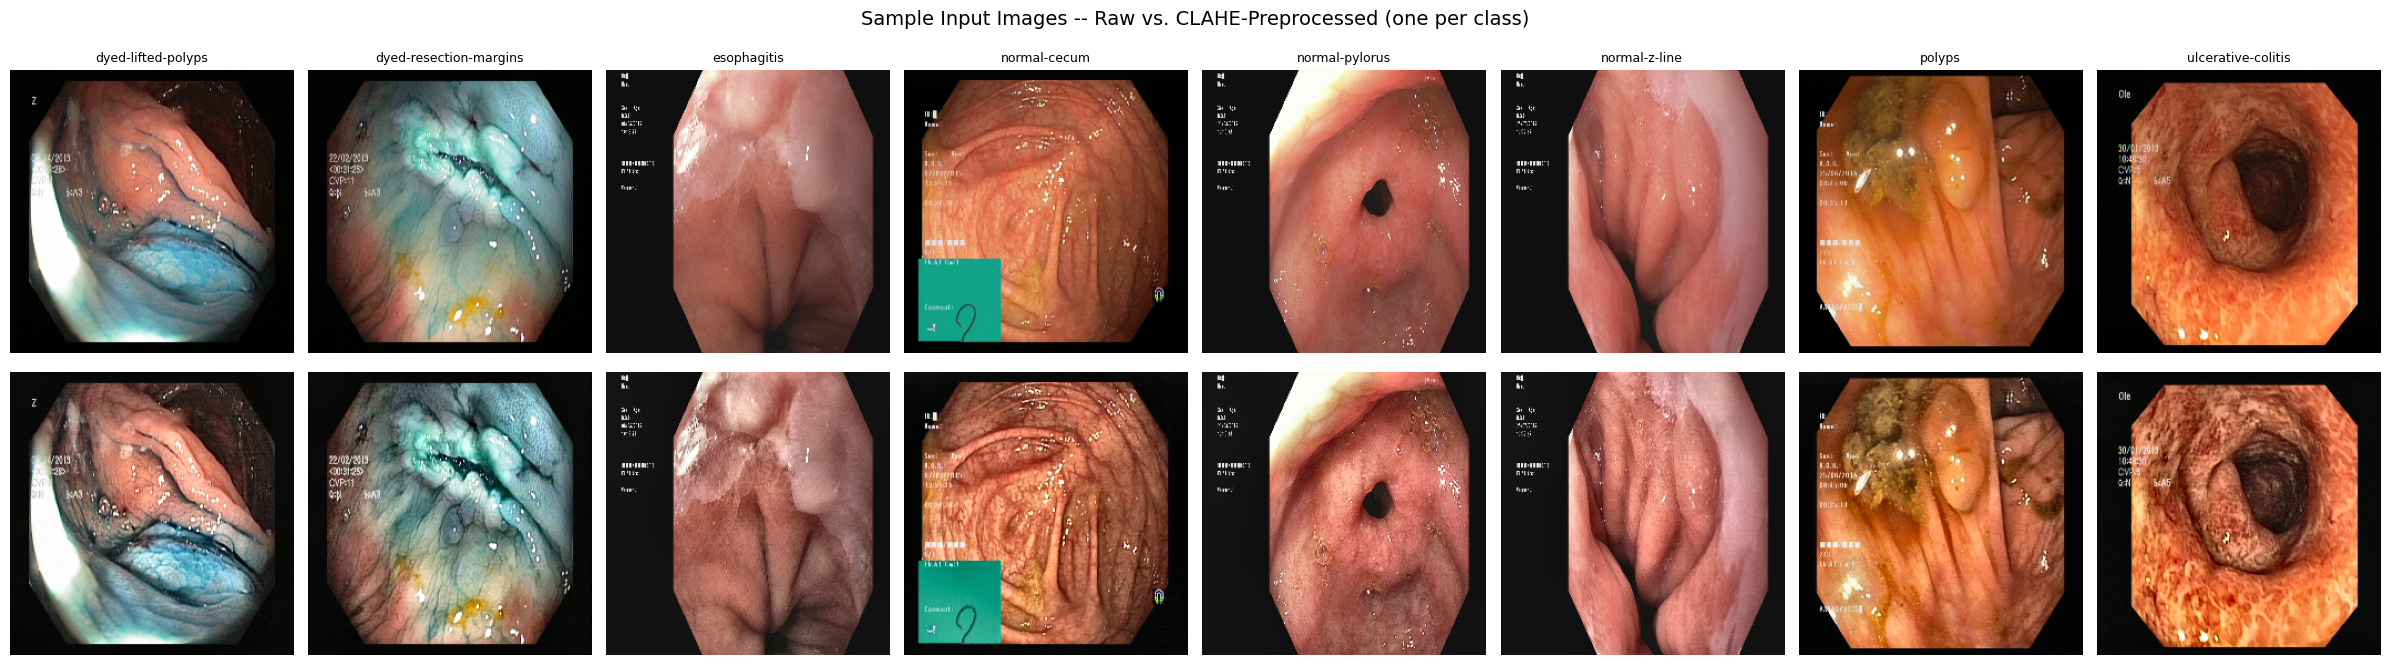

In [7]:
# ============================================================
# 5A. SAMPLE INPUT GRID -- raw vs. CLAHE-preprocessed, one image per class
# ============================================================
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(3 * NUM_CLASSES, 7))
for col, cname in enumerate(CLASS_NAMES):
    sample_path = train_df[train_df['label'] == class_to_idx[cname]]['filepath'].iloc[0]

    raw_img = cv2.imread(sample_path)
    raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    raw_img = cv2.resize(raw_img, (IMG_SIZE, IMG_SIZE))

    processed_img = load_and_preprocess(sample_path)

    axes[0, col].imshow(raw_img)
    axes[0, col].set_title(cname, fontsize=9)
    axes[0, col].axis('off')

    axes[1, col].imshow(processed_img)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Raw', fontsize=12)
axes[1, 0].set_ylabel('After CLAHE', fontsize=12)
plt.suptitle('Sample Input Images -- Raw vs. CLAHE-Preprocessed (one per class)', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/fig_sample_inputs.png', dpi=150)
plt.show()


In [8]:
# ============================================================
# 6. AUGMENTATION PIPELINE
# ============================================================
def build_train_transforms():
    # Return fresh instances: ReplayCompose marks its child transforms as replay-aware.
    return [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.Rotate(limit=90, p=0.4),
        A.Affine(translate_percent=0.05, scale=(0.85, 1.15), rotate=(-20, 20), p=0.5),
        A.ElasticTransform(alpha=100, sigma=5, p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.GaussianBlur(blur_limit=3, p=0.2),
        A.GaussNoise(std_range=(0.01, 0.03), p=0.3),
    ]

train_transform = A.Compose(build_train_transforms())

val_test_transform = A.Compose([])  # no augmentation, CLAHE already applied in preprocessing


            Augmentation  Times Applied Percentage
          HorizontalFlip            253      50.6%
            VerticalFlip            150      30.0%
                  Rotate            178      35.6%
                  Affine            228      45.6%
        ElasticTransform            228      45.6%
RandomBrightnessContrast            235      47.0%
            GaussianBlur             92      18.4%
              GaussNoise            165      33.0%


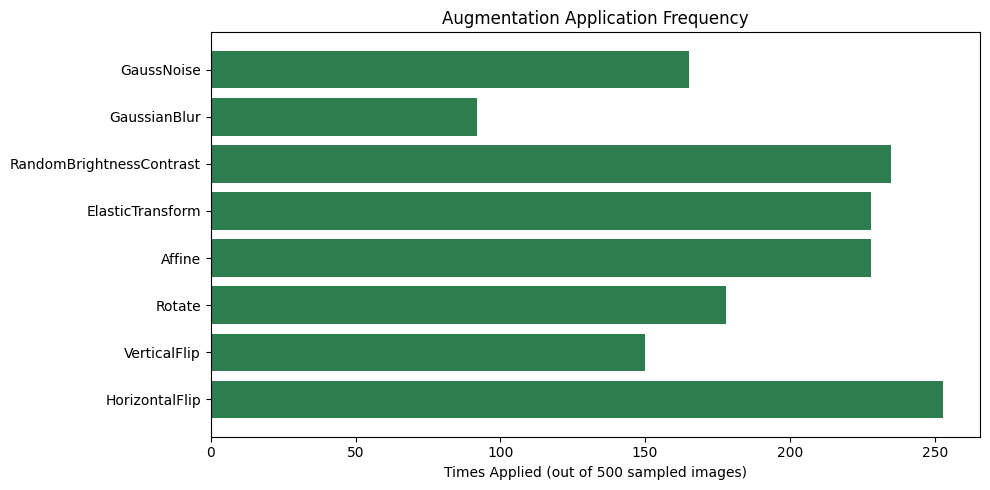

In [9]:
# ============================================================
# 6A. AUGMENTATION COUNT -- inspect stochastic training views
#     Uses separate transform instances so ReplayCompose cannot affect training.
# ============================================================
train_transform_replay = A.ReplayCompose(build_train_transforms())

aug_counts = {t.__class__.__name__: 0 for t in train_transform_replay.transforms}
N_SAMPLE = 500
sample_paths = train_df['filepath'].sample(min(N_SAMPLE, len(train_df)), random_state=SEED).tolist()

for path in sample_paths:
    img = load_and_preprocess(path)
    img_uint8 = (img * 255).astype(np.uint8)
    result = train_transform_replay(image=img_uint8)
    for item in result['replay']['transforms']:
        if item['applied']:
            name = item['__class_fullname__'].split('.')[-1]
            aug_counts[name] = aug_counts.get(name, 0) + 1

aug_df = pd.DataFrame({
    'Augmentation': list(aug_counts.keys()),
    'Times Applied': list(aug_counts.values()),
    'Percentage': [f"{v/len(sample_paths)*100:.1f}%" for v in aug_counts.values()],
})
print(aug_df.to_string(index=False))
aug_df.to_csv('/kaggle/working/table_augmentation_counts.csv', index=False)

plt.figure(figsize=(10, 5))
plt.barh(aug_df['Augmentation'], list(aug_counts.values()), color='#2E7D4F')
plt.xlabel(f'Times Applied (out of {len(sample_paths)} sampled images)')
plt.title('Augmentation Application Frequency')
plt.tight_layout()
plt.savefig('/kaggle/working/fig_augmentation_counts.png', dpi=150)
plt.show()


In [10]:
# ============================================================
# 7. tf.data PIPELINE
# ============================================================
def make_generator(dataframe, augment=False):
    def gen():
        for _, row in dataframe.iterrows():
            img = load_and_preprocess(row['filepath'])
            if augment:
                img_uint8 = (img * 255).astype(np.uint8)
                augmented = train_transform(image=img_uint8)['image']
                img = augmented.astype(np.float32) / 255.0
            label = to_categorical(row['label'], num_classes=NUM_CLASSES)
            yield img, label
    return gen

def build_dataset(dataframe, augment=False, shuffle=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_generator(
        make_generator(dataframe, augment=augment),
        output_signature=(
            tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(NUM_CLASSES,), dtype=tf.float32),
        )
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = build_dataset(train_df, augment=True, shuffle=True)
val_ds   = build_dataset(val_df,   augment=False, shuffle=False)
test_ds  = build_dataset(test_df,  augment=False, shuffle=False)


I0000 00:00:1788537205.059430      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [11]:
# ============================================================
# 8. CBAM ATTENTION MODULE
# ============================================================
def cbam_block(x, reduction_ratio=16):
    channels = x.shape[-1]

    avg_pool = layers.GlobalAveragePooling2D()(x)
    max_pool = layers.GlobalMaxPooling2D()(x)

    shared_dense_1 = layers.Dense(max(1, channels // reduction_ratio), activation='relu')
    shared_dense_2 = layers.Dense(channels, activation=None)

    avg_out = shared_dense_2(shared_dense_1(avg_pool))
    max_out = shared_dense_2(shared_dense_1(max_pool))

    channel_att = layers.Activation('sigmoid')(layers.Add()([avg_out, max_out]))
    channel_att = layers.Reshape((1, 1, channels))(channel_att)
    x = layers.Multiply()([x, channel_att])

    avg_pool_s = keras.ops.mean(x, axis=-1, keepdims=True)
    max_pool_s = keras.ops.max(x, axis=-1, keepdims=True)
    concat = layers.Concatenate(axis=-1)([avg_pool_s, max_pool_s])
    spatial_att = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)
    x = layers.Multiply()([x, spatial_att])

    return x


In [12]:
# ============================================================
# 9. GLOBAL SELF-ATTENTION BOTTLENECK (available experimental component)
# ============================================================
class GlobalAttentionBlock(layers.Layer):
    def __init__(self, dim=1024, num_heads=8, mlp_ratio=4, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.num_heads = num_heads
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=dim // num_heads)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = models.Sequential([
            layers.Dense(dim * mlp_ratio, activation='gelu'),
            layers.Dense(dim)
        ])

    def call(self, x):
        B, H, W, C = x.shape
        shortcut = x
        x = self.norm1(x)
        tokens = tf.reshape(x, [-1, H * W, C])
        attn_out = self.attn(tokens, tokens)
        x = tf.reshape(attn_out, [-1, H, W, C])
        x = shortcut + x
        shortcut2 = x
        x = self.norm2(x)
        x = self.mlp(x)
        x = shortcut2 + x
        return x

def attention_bottleneck(x, dim=1024, num_heads=8, num_blocks=2):
    x = layers.Conv2D(dim, 1, padding='same')(x)
    for _ in range(num_blocks):
        x = GlobalAttentionBlock(dim=dim, num_heads=num_heads)(x)
    return x


In [13]:
# ============================================================
# 10. BASELINE MODEL BUILDERS -- fine-tuned EfficientNetB0 (last 20 layers unfrozen)
# ============================================================
def build_backbone(input_shape):
    base = tf.keras.applications.EfficientNetB0(
        include_top=False, weights='imagenet', input_shape=input_shape
    )
    base.trainable = True
    for layer in base.layers[:-20]:
        layer.trainable = False
    return base

def build_plain_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)
    base = build_backbone(input_shape)
    x = base(inputs * 255.0, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name='PlainCNN')

def build_cnn_cbam(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)
    base = build_backbone(input_shape)
    x = base(inputs * 255.0, training=False)
    x = cbam_block(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name='CNN_CBAM')

def build_swin_tiny(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)
    x = layers.Resizing(SWIN_SIZE, SWIN_SIZE)(inputs * 255.0)
    x = layers.Rescaling(1.0 / 255.0)(x)
    SwinBackbone = getattr(keras_hub.models, "SwinTransformerBackbone", getattr(keras_hub.models, "SwinBackbone", None))
    if SwinBackbone is None:
        raise AttributeError("module 'keras_hub.models' has no attribute 'SwinTransformerBackbone' or 'SwinBackbone'. Please run '!pip install -q -U keras-hub' and restart your runtime.")
    swin = SwinBackbone.from_preset(
        'swin_tiny_patch4_window7_224', drop_path=0.0
    )
    x = swin(x)
    x = layers.Reshape((-1, x.shape[-1]))(x)  # feature map -> token sequence
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name='SwinTiny')


In [14]:
# ============================================================
# 11. MULTI-SCALE CBAM FUSION (proven best single-branch model, 89.75% acc)
# ============================================================
def get_multiscale_backbone(input_shape):
    base = tf.keras.applications.EfficientNetB0(
        include_top=False, weights='imagenet', input_shape=input_shape
    )
    base.trainable = True
    for layer in base.layers[:-20]:
        layer.trainable = False

    target_resolutions = [32, 16, 8]
    scale_outputs = {}
    for layer in base.layers:
        shape = layer.output.shape
        if shape is None or len(shape) != 4 or shape[1] is None:
            continue
        h = shape[1]
        if h in target_resolutions:
            scale_outputs[h] = layer.output

    outputs = [scale_outputs[r] for r in target_resolutions if r in scale_outputs]
    return models.Model(inputs=base.input, outputs=outputs, name='efficientnet_multiscale')

def build_multiscale_cbam_fusion(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)
    backbone = get_multiscale_backbone(input_shape)
    feats = backbone(inputs * 255.0, training=False)

    attended = []
    for f in feats:
        f = cbam_block(f)
        f = layers.Conv2D(256, 1, padding='same')(f)
        attended.append(f)

    target_size = attended[-1].shape[1]
    resized = []
    for f in attended:
        h = f.shape[1]
        if h != target_size:
            f = layers.AveragePooling2D(h // target_size)(f)
        resized.append(f)

    fused = layers.Concatenate(axis=-1)(resized)
    fused = layers.Conv2D(512, 1, padding='same', activation='relu')(fused)
    fused = layers.BatchNormalization()(fused)

    x = layers.GlobalAveragePooling2D()(fused)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name='MultiScale_CBAM_Fusion')


In [15]:
# ============================================================
# 12. PROPOSED MODEL: Cross-Attention CNN + Swin Transformer Dual-Branch
#     Branch A: multi-scale CNN+CBAM (same backbone as above, returns tokens)
#     Branch B: genuinely pretrained Swin-Tiny (ImageNet weights via keras_hub)
#     Fusion:   learned, bidirectional cross-attention between the two branches
# ============================================================
def build_cnn_branch_tokens(inputs):
    backbone = get_multiscale_backbone((IMG_SIZE, IMG_SIZE, 3))
    feats = backbone(inputs * 255.0, training=False)
    attended = []
    for f in feats:
        f = cbam_block(f)
        f = layers.Conv2D(512, 1, padding='same')(f)
        attended.append(f)
    target_size = attended[-1].shape[1]
    resized = []
    for f in attended:
        h = f.shape[1]
        if h != target_size:
            f = layers.AveragePooling2D(h // target_size)(f)
        resized.append(f)
    fused = layers.Concatenate(axis=-1)(resized)
    fused = layers.Conv2D(512, 1, padding='same', activation='relu', name='cnn_fused_conv')(fused)
    fused = layers.BatchNormalization(name='cnn_fused_features')(fused)   # (B, 8, 8, 512) <- Grad-CAM target
    tokens = layers.Reshape((fused.shape[1] * fused.shape[2], 512))(fused)  # (B, 64, 512)
    return tokens

def build_swin_branch_tokens(inputs):
    resized = layers.Resizing(SWIN_SIZE, SWIN_SIZE)(inputs * 255.0)
    resized = layers.Rescaling(1.0 / 255.0)(resized)
    SwinBackbone = getattr(keras_hub.models, "SwinTransformerBackbone", getattr(keras_hub.models, "SwinBackbone", None))
    if SwinBackbone is None:
        raise AttributeError("module 'keras_hub.models' has no attribute 'SwinTransformerBackbone' or 'SwinBackbone'. Please run '!pip install -q -U keras-hub' and restart your runtime.")
    swin = SwinBackbone.from_preset(
        "swin_tiny_patch4_window7_224",
        drop_path=0.0,  # avoids a keras_hub bug (ops.random.uniform mismatch during training);
                         # DropPath has no weights, so this doesn't affect the pretrained weights
    )
    features = swin(resized)  # (B, 7, 7, 768) in the KerasHub Swin-Tiny preset
    tokens = layers.Reshape((-1, features.shape[-1]), name='swin_tokens')(features)  # (B, 49, 768)
    return tokens

def cross_attention_fusion(cnn_tokens, swin_tokens, dim=512, num_heads=8):
    swin_proj = layers.Dense(dim)(swin_tokens)

    cnn_attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=dim // num_heads)(
        query=cnn_tokens, key=swin_proj, value=swin_proj)
    cnn_refined = layers.LayerNormalization(epsilon=1e-6)(cnn_tokens + cnn_attn)

    swin_attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=dim // num_heads)(
        query=swin_proj, key=cnn_tokens, value=cnn_tokens)
    swin_refined = layers.LayerNormalization(epsilon=1e-6)(swin_proj + swin_attn)

    cnn_pooled = layers.GlobalAveragePooling1D()(cnn_refined)
    swin_pooled = layers.GlobalAveragePooling1D()(swin_refined)
    return layers.Concatenate()([cnn_pooled, swin_pooled])

def build_cross_attention_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)
    cnn_tokens = build_cnn_branch_tokens(inputs)
    swin_tokens = build_swin_branch_tokens(inputs)
    fused = cross_attention_fusion(cnn_tokens, swin_tokens)
    x = layers.Dense(256, activation='relu')(fused)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name='CrossAttention_CNN_Swin')


In [16]:
# ============================================================
# 13. LR SCHEDULE: 15-epoch linear warmup + cosine annealing
#     base_lr=1e-5 -- matches the fine-tuning optimizer LR (must stay in sync)
# ============================================================
class WarmupCosineSchedule(callbacks.Callback):
    def __init__(self, base_lr=1e-5, warmup_epochs=15, total_epochs=EPOCHS):
        super().__init__()
        self.base_lr = base_lr
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.base_lr * (epoch + 1) / self.warmup_epochs
        else:
            p = (epoch - self.warmup_epochs) / max(1, (self.total_epochs - self.warmup_epochs))
            lr = self.base_lr * 0.5 * (1 + math.cos(math.pi * p))
        self.model.optimizer.learning_rate.assign(lr)


In [17]:
# ============================================================
# 14. TRAIN + EVALUATE FUNCTIONS
# ============================================================
def compile_and_train(model, train_ds, val_ds, epochs=EPOCHS, tag='model'):
    optimizer = optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-4)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy',
                   metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)])
    ckpt_path = f'/kaggle/working/{tag}_best.keras'
    cbs = [
        WarmupCosineSchedule(base_lr=1e-5, warmup_epochs=15, total_epochs=epochs),
        callbacks.ModelCheckpoint(ckpt_path, monitor='val_accuracy', save_best_only=True),
        callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    ]
    # Let Keras consume each finite dataset completely, including its last partial batch.
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs,
                         callbacks=cbs, verbose=1)
    return history, ckpt_path

def evaluate_model(model, test_ds, test_df, class_names):
    y_true, y_pred_probs = [], []
    for x_batch, y_batch in test_ds:
        preds = model.predict(x_batch, verbose=0)
        y_pred_probs.extend(preds)
        y_true.extend(y_batch.numpy())

    y_true = np.array(y_true)
    y_pred_probs = np.array(y_pred_probs)
    y_true_labels = np.argmax(y_true, axis=1)
    y_pred_labels = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_true_labels, y_pred_labels)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true_labels, y_pred_labels, average='macro', zero_division=0)
    auc = roc_auc_score(y_true, y_pred_probs, multi_class='ovr', average='macro')
    cm = confusion_matrix(y_true_labels, y_pred_labels)

    specs = []
    for i in range(len(class_names)):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        specs.append(tn / (tn + fp + 1e-8))
    specificity = np.mean(specs)

    print(classification_report(y_true_labels, y_pred_labels, target_names=class_names))

    return {
        'accuracy': acc, 'precision': precision, 'recall': recall,
        'f1': f1, 'specificity': specificity, 'auc': auc,
        'confusion_matrix': cm, 'y_true': y_true_labels, 'y_pred_probs': y_pred_probs
    }


In [18]:
# ============================================================
# 15. TRAIN ALL FIVE MODELS
# ============================================================
model_builders = {
    'PlainCNN': build_plain_cnn,
    'CNN_CBAM': build_cnn_cbam,
    'SwinTiny': build_swin_tiny,
    'MultiScale_CBAM_Fusion': build_multiscale_cbam_fusion,
    'CrossAttention_CNN_Swin': build_cross_attention_model,
}

results = {}
histories = {}
param_counts = {}
trained_models = {}

for name, builder in model_builders.items():
    print(f"\n{'='*60}\nTraining: {name}\n{'='*60}")
    model = builder()
    total_params = model.count_params()
    trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
    param_counts[name] = {'total': total_params, 'trainable': trainable_params}

    history, ckpt_path = compile_and_train(model, train_ds, val_ds, epochs=EPOCHS, tag=name)
    histories[name] = history
    trained_models[name] = model

    eval_result = evaluate_model(model, test_ds, test_df, CLASS_NAMES)
    results[name] = eval_result

    print(f"{name} -> Acc: {eval_result['accuracy']:.4f}  F1: {eval_result['f1']:.4f}  AUC: {eval_result['auc']:.4f}")



Training: PlainCNN
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1788537342.953265      80 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    399/Unknown 141s 17ms/step - accuracy: 0.1203 - auc: 0.5468 - loss: 2.1039

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


400/400 ━━━━━━━━━━━━━━━━━━━━ 162s 71ms/step - accuracy: 0.1203 - auc: 0.5463 - loss: 2.1039 - val_accuracy: 0.1225 - val_auc: 0.5830 - val_loss: 2.0815
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 83s 35ms/step - accuracy: 0.1425 - auc: 0.5960 - loss: 2.0596 - val_accuracy: 0.1575 - val_auc: 0.6643 - val_loss: 1.9968
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 81s 35ms/step - accuracy: 0.1841 - auc: 0.6615 - loss: 1.9885 - val_accuracy: 0.2225 - val_auc: 0.7675 - val_loss: 1.8807
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 85s 36ms/step - accuracy: 0.2581 - auc: 0.7465 - loss: 1.8883 - val_accuracy: 0.3275 - val_auc: 0.8593 - val_loss: 1.7388
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 82s 35ms/step - accuracy: 0.3512 - auc: 0.8128 - loss: 1.7795 - val_accuracy: 0.4350 - val_auc: 0.9208 - val_loss: 1.5790
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 80s 34ms/step - accuracy: 0.4525 - auc: 0.8716 - loss: 1.6430 - val_accuracy: 0.5775 - val_auc: 0.9520 - val_loss: 1.3935
Epoch 7/100
400/400 ━━━━━━━━━━━━━

...

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


    400/Unknown 229s 89ms/step - accuracy: 0.2119 - auc: 0.6211 - loss: 2.1005

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


400/400 ━━━━━━━━━━━━━━━━━━━━ 265s 177ms/step - accuracy: 0.2119 - auc: 0.6211 - loss: 2.1005 - val_accuracy: 0.3725 - val_auc: 0.8039 - val_loss: 1.6779
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 115s 115ms/step - accuracy: 0.4150 - auc: 0.8136 - loss: 1.5749 - val_accuracy: 0.6775 - val_auc: 0.9453 - val_loss: 1.0976
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 116s 115ms/step - accuracy: 0.6234 - auc: 0.9302 - loss: 1.0271 - val_accuracy: 0.7750 - val_auc: 0.9785 - val_loss: 0.6606
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 118s 116ms/step - accuracy: 0.7337 - auc: 0.9654 - loss: 0.7014 - val_accuracy: 0.8525 - val_auc: 0.9875 - val_loss: 0.4399
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 117s 116ms/step - accuracy: 0.8044 - auc: 0.9785 - loss: 0.5226 - val_accuracy: 0.8625 - val_auc: 0.9910 - val_loss: 0.3622
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 115s 115ms/step - accuracy: 0.8466 - auc: 0.9847 - loss: 0.4258 - val_accuracy: 0.8875 - val_auc: 0.9936 - val_loss: 0.2968
Epoch 7/100
400/400 ━━

In [19]:
# ============================================================
# 16. TABLE 1 -- Parameter Summary
# ============================================================
param_df = pd.DataFrame(param_counts).T
param_df.columns = ['Total Params', 'Trainable Params']
print(param_df)
param_df.to_csv('/kaggle/working/table1_param_summary.csv')


                         Total Params  Trainable Params
PlainCNN                      4379563           1680952
CNN_CBAM                      4585822           1887211
SwinTiny                     27718274          27718274
MultiScale_CBAM_Fusion        5411725           2712090
CrossAttention_CNN_Swin      36514311          33814676


In [20]:
# ============================================================
# 17. TABLE 3 -- Performance Comparison Across All 5 Models
# ============================================================
metrics_rows = []
for name, r in results.items():
    metrics_rows.append({
        'Model': name,
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1': r['f1'],
        'Specificity': r['specificity'],
        'AUC': r['auc'],
    })
metrics_df = pd.DataFrame(metrics_rows)
print(metrics_df)
metrics_df.to_csv('/kaggle/working/table3_performance_comparison.csv', index=False)


                     Model  Accuracy  Precision  Recall        F1  \
0                 PlainCNN    0.9025   0.904057  0.9025  0.901986   
1                 CNN_CBAM    0.9000   0.901832  0.9000  0.899573   
2                 SwinTiny    0.9275   0.928293  0.9275  0.927610   
3   MultiScale_CBAM_Fusion    0.8900   0.890934  0.8900  0.889431   
4  CrossAttention_CNN_Swin    0.9250   0.926115  0.9250  0.924984   

   Specificity       AUC  
0     0.986071  0.993707  
1     0.985714  0.993914  
2     0.989643  0.994571  
3     0.984286  0.993286  
4     0.989286  0.996579  


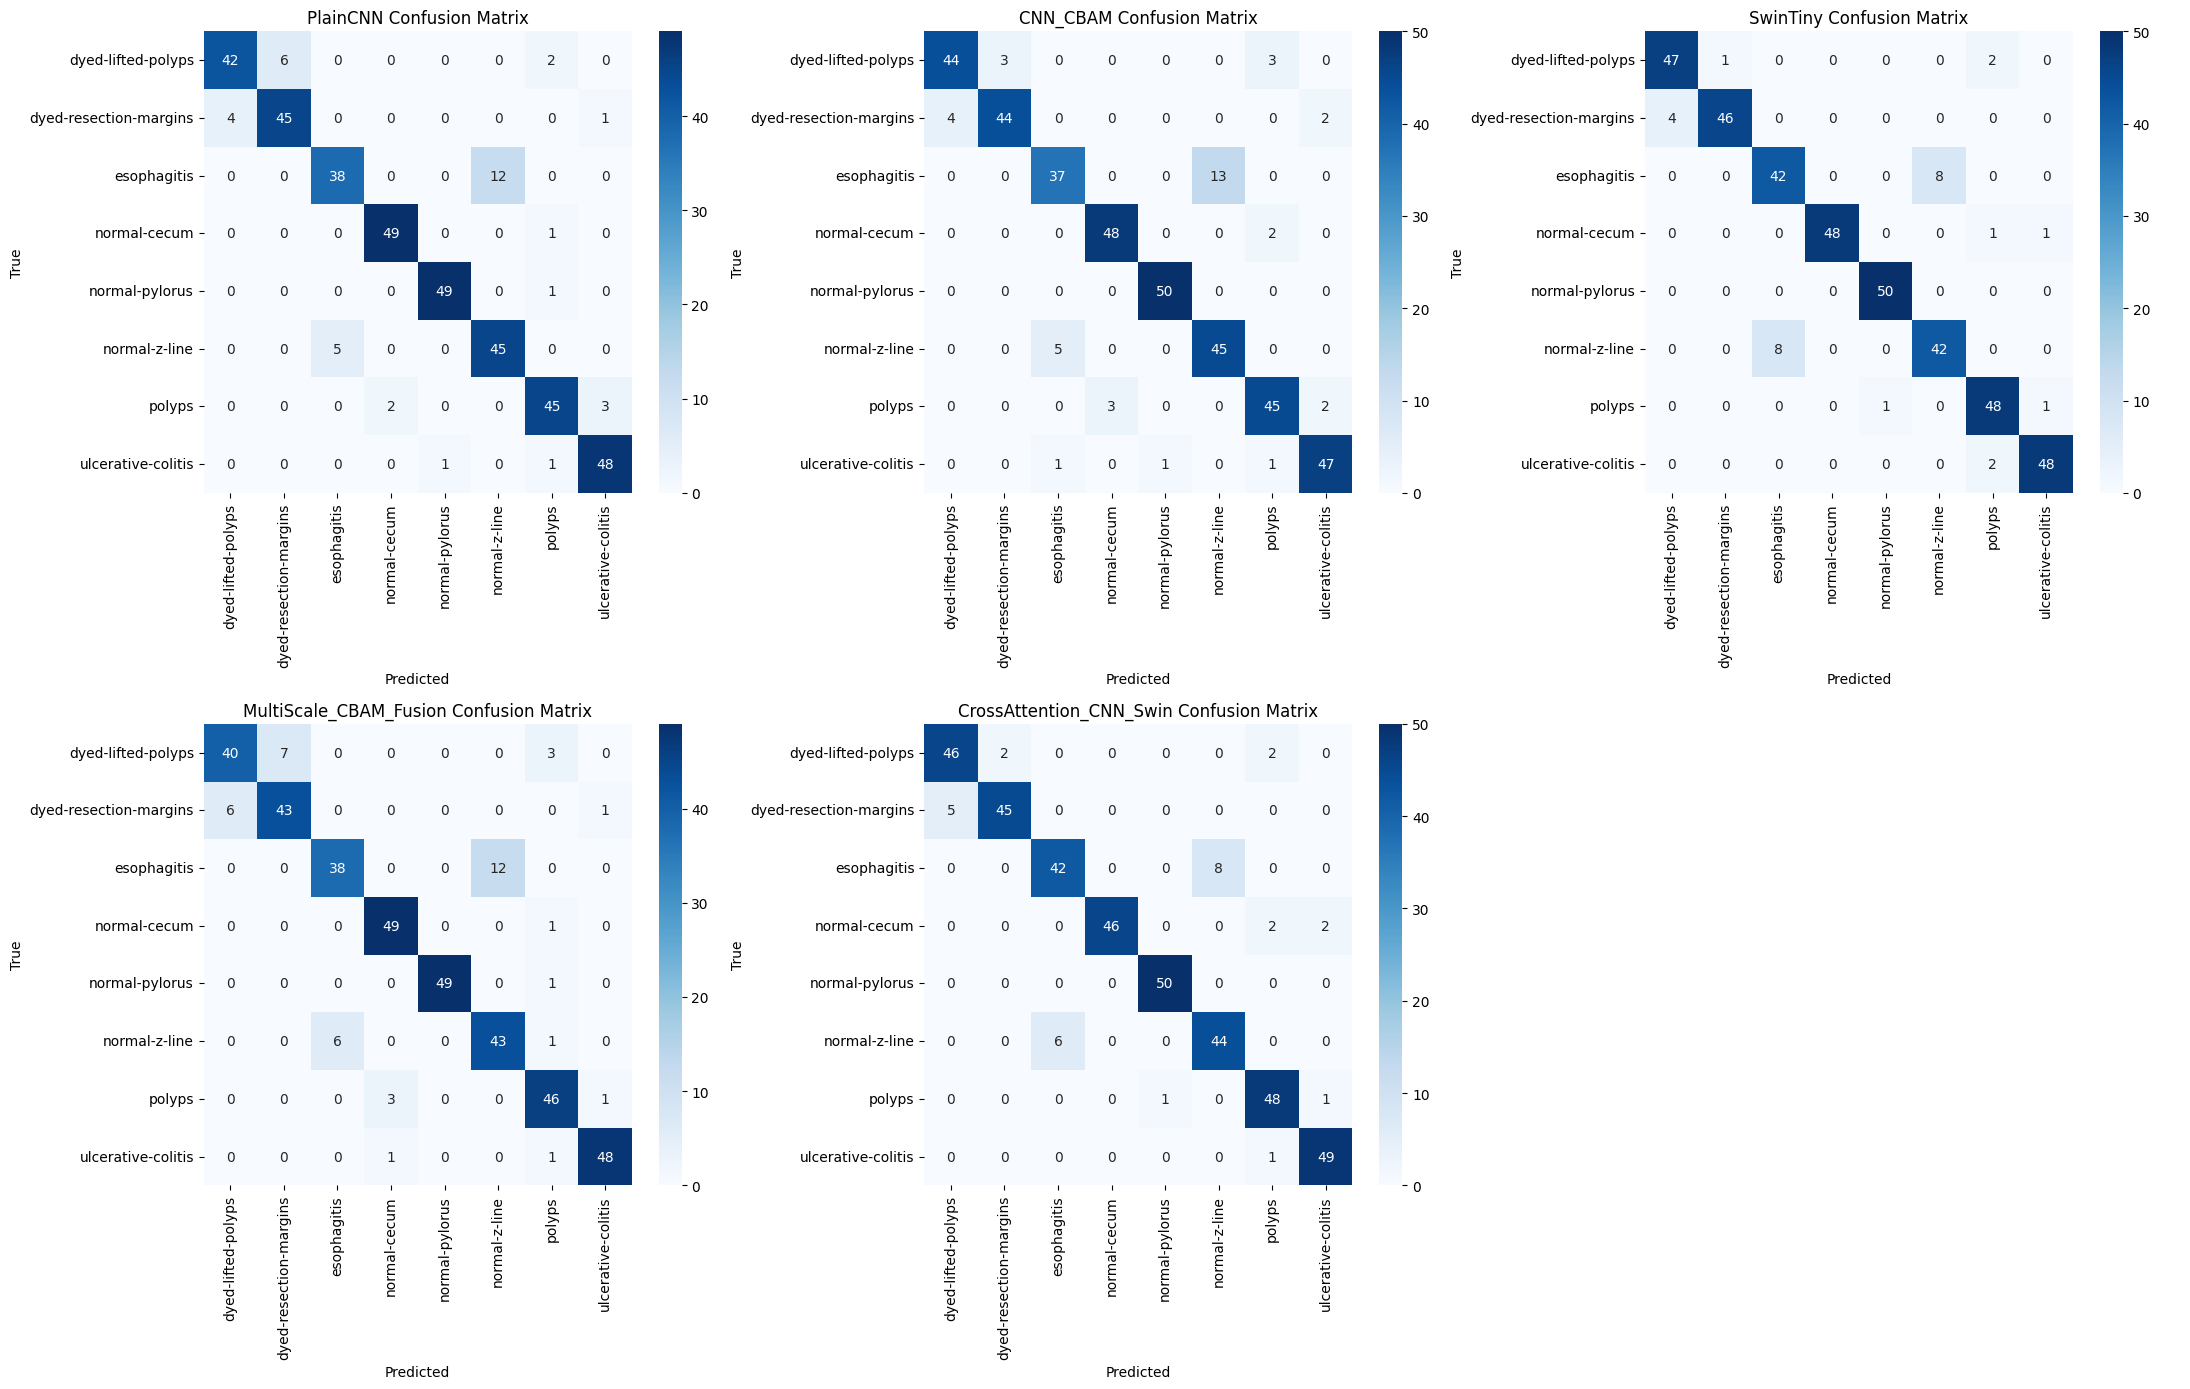

In [21]:
# ============================================================
# 18. Confusion Matrices (all 5 models)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
for ax, (name, r) in zip(axes.flatten(), results.items()):
    sns.heatmap(r['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
for ax in axes.flatten()[len(results):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/fig_confusion_matrices.png', dpi=150)
plt.show()


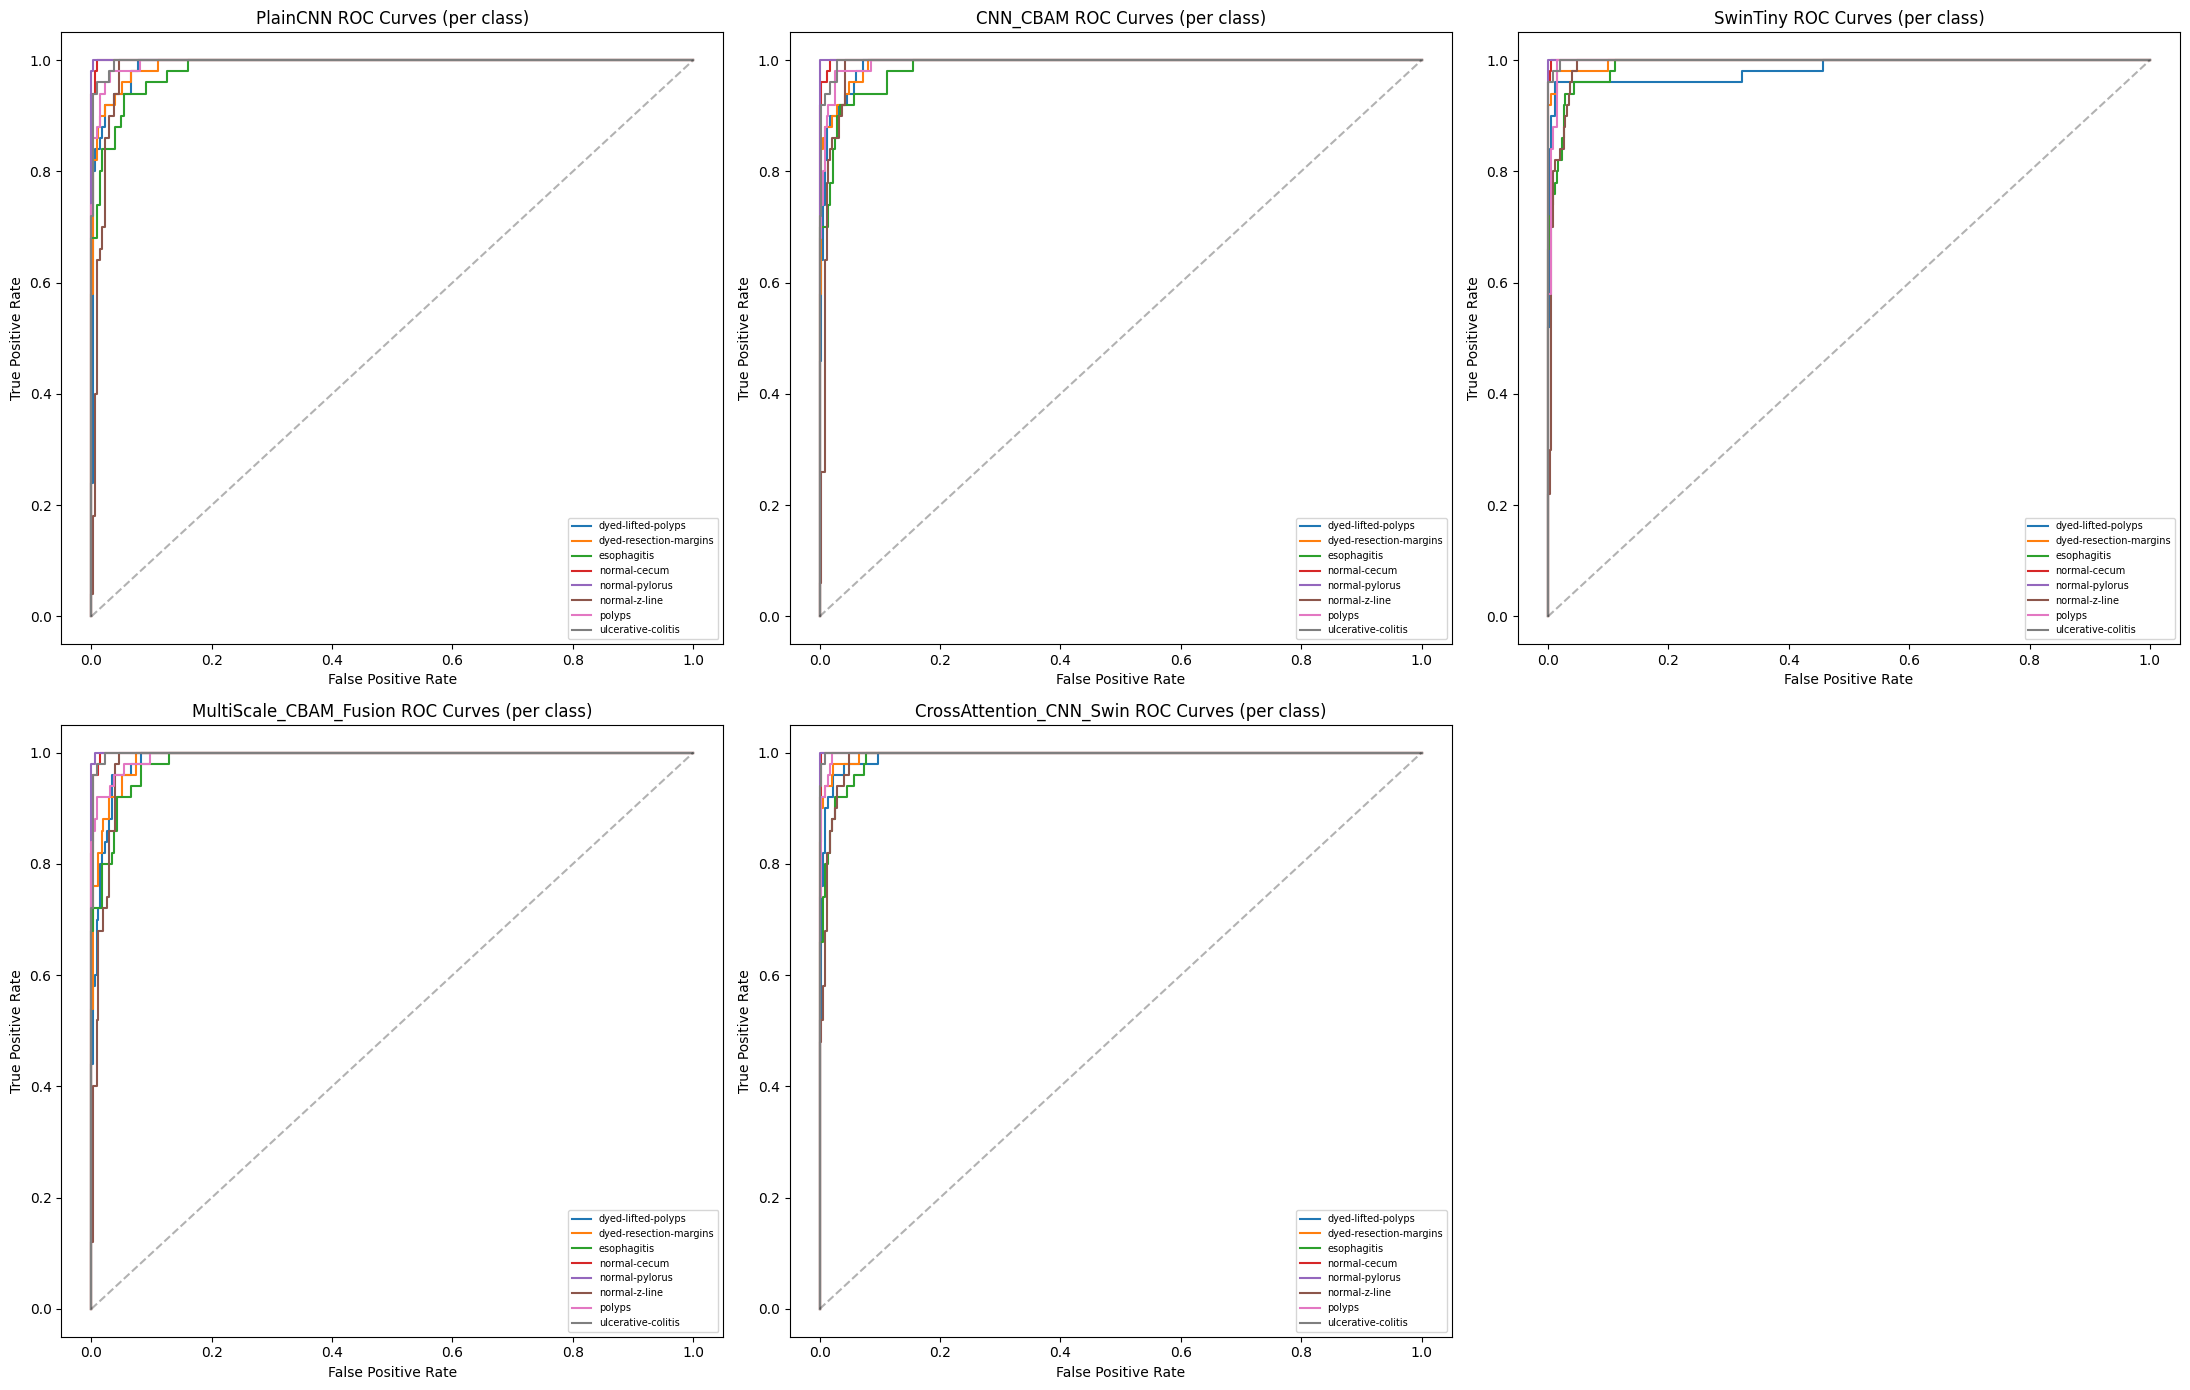

In [22]:
# ============================================================
# 19. ROC-AUC Curves (one-vs-rest, per model)
# ============================================================
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
for ax, (name, r) in zip(axes.flatten(), results.items()):
    y_true_bin = label_binarize(r['y_true'], classes=list(range(NUM_CLASSES)))
    for i, cname in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], r['y_pred_probs'][:, i])
        ax.plot(fpr, tpr, label=f'{cname}')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(f'{name} ROC Curves (per class)')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7, loc='lower right')
for ax in axes.flatten()[len(results):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/fig_roc_curves.png', dpi=150)
plt.show()


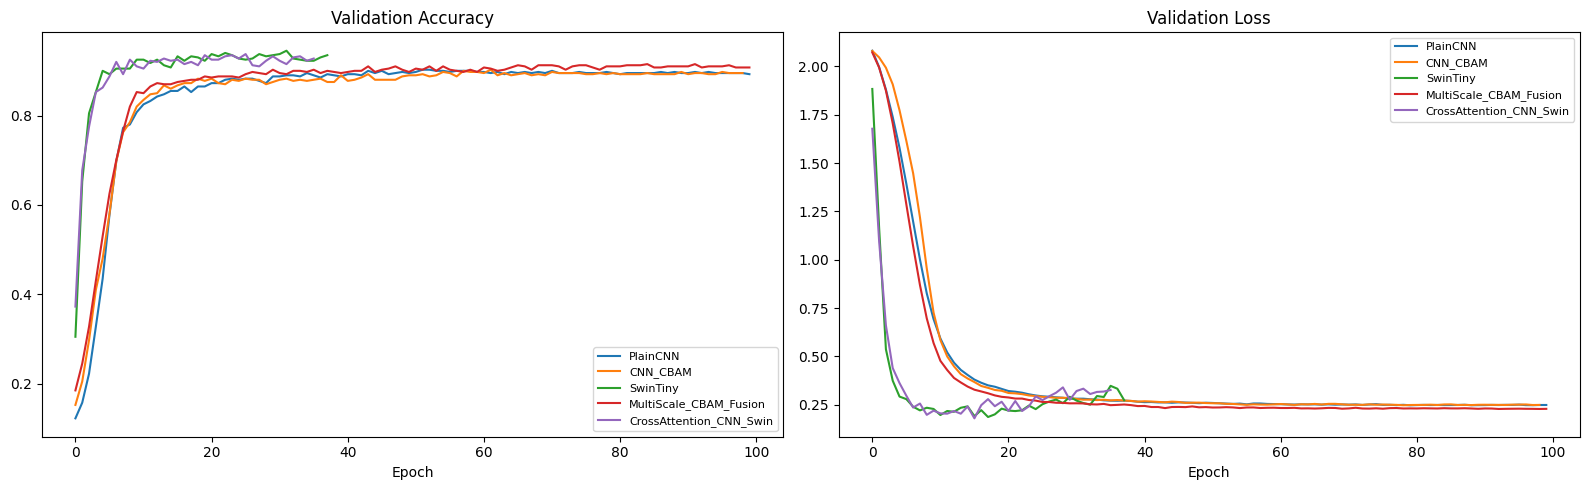

In [23]:
# ============================================================
# 20. Training Curves -- all 5 models
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for name, h in histories.items():
    axes[0].plot(h.history['val_accuracy'], label=name)
    axes[1].plot(h.history['val_loss'], label=name)
axes[0].set_title('Validation Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=8)
axes[1].set_title('Validation Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig('/kaggle/working/fig_training_curves.png', dpi=150)
plt.show()


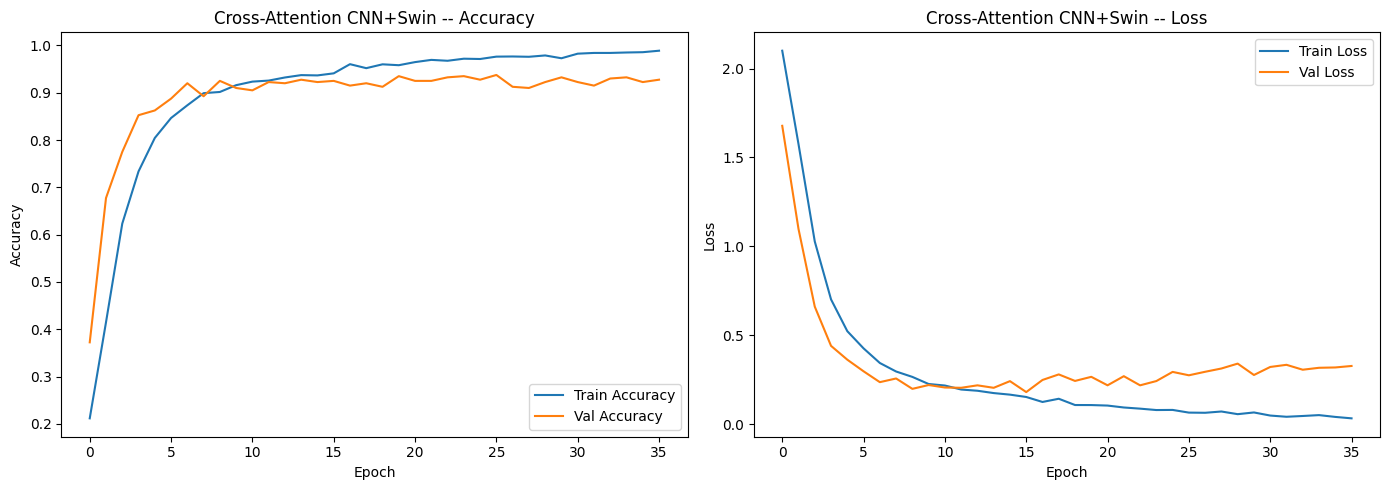

In [24]:
# ============================================================
# 20A. Cross-Attention CNN+Swin -- dedicated training/loss curves
# ============================================================
h = histories['CrossAttention_CNN_Swin'].history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(h['accuracy'], label='Train Accuracy')
axes[0].plot(h['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Cross-Attention CNN+Swin -- Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

axes[1].plot(h['loss'], label='Train Loss')
axes[1].plot(h['val_loss'], label='Val Loss')
axes[1].set_title('Cross-Attention CNN+Swin -- Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/fig_crossattn_training_curves.png', dpi=150)
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_855']
Received: inputs=Tensor(shape=(1, 256, 256, 3))
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1039: UserWarning: Layer 'attn' (of type WindowAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


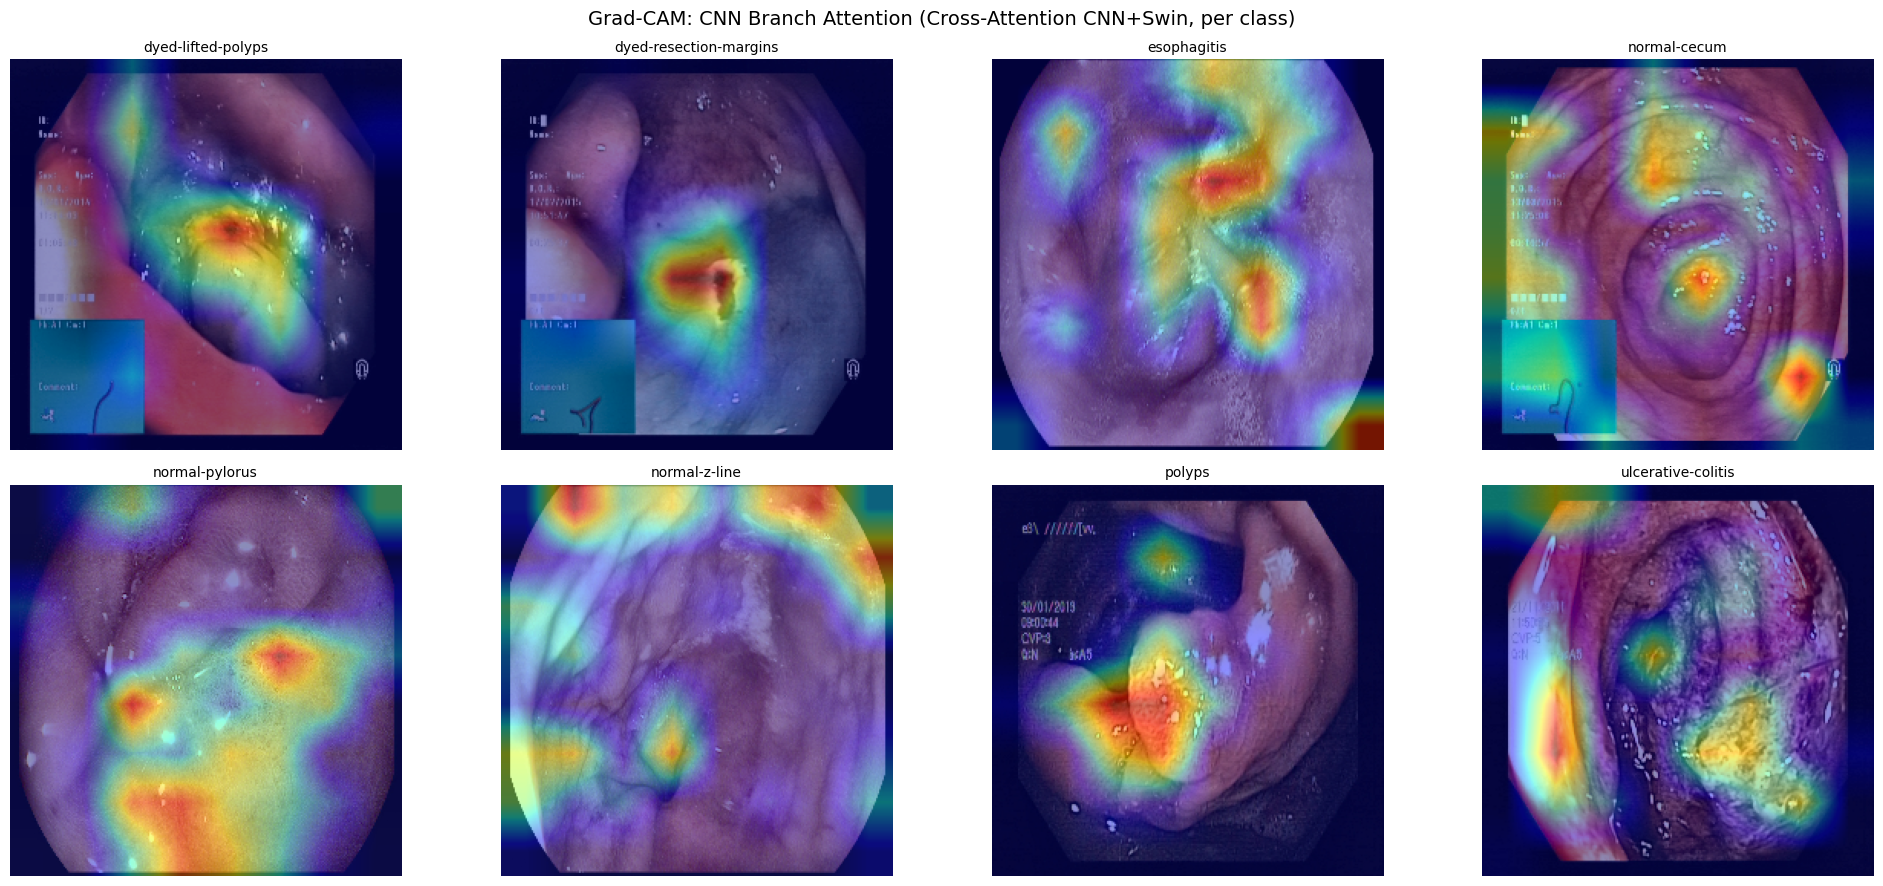

In [25]:
# ============================================================
# 21. GRAD-CAM -- visual interpretation of the CNN branch (proposed model)
# ============================================================
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

cross_attn_model = trained_models['CrossAttention_CNN_Swin']

fig, axes = plt.subplots(2, NUM_CLASSES // 2 + NUM_CLASSES % 2, figsize=(20, 9))
for ax, cname in zip(axes.flatten(), CLASS_NAMES):
    sample_row = test_df[test_df['label'] == class_to_idx[cname]].iloc[0]
    img = load_and_preprocess(sample_row['filepath'])
    img_batch = np.expand_dims(img, axis=0)

    heatmap = make_gradcam_heatmap(img_batch, cross_attn_model, 'cnn_fused_features')
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))

    ax.imshow(img)
    ax.imshow(heatmap_resized, cmap='jet', alpha=0.45)
    ax.set_title(cname, fontsize=10)
    ax.axis('off')
for ax in axes.flatten()[NUM_CLASSES:]:
    ax.axis('off')

plt.suptitle('Grad-CAM: CNN Branch Attention (Cross-Attention CNN+Swin, per class)', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/fig_gradcam.png', dpi=150)
plt.show()


## Notes

- **5 models compared**: PlainCNN, CNN+CBAM, pretrained SwinTiny, MultiScale_CBAM_Fusion (previous best, 89.75%), and CrossAttention_CNN_Swin (the proposed model -- pretrained Swin-Tiny + multi-scale CNN+CBAM, fused through learned cross-attention).
- **Batch coverage fixed**: training and validation now include their final partial batch rather than silently dropping it.
- **LR bug fixed**: `WarmupCosineSchedule` now uses `base_lr=1e-5`, matching the optimizer -- previous runs had a mismatch (`3e-4`) that silently overrode the intended fine-tuning learning rate every epoch.
- **Run the quick EPOCHS=2 sanity check first** before committing to a full run -- CrossAttention_CNN_Swin is the heaviest model (~36M+ params, two full backbones), watch for GPU memory issues.
- **If OOM occurs** on the CrossAttention model specifically, reduce BATCH_SIZE for that model only, or reduce IMG_SIZE.
